# Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Description of the Visualization Function

The `analyze_frequencies` function performs comparative stylometric analysis between human-written and AI-generated Arabic text. The function:

1. **Data Loading**: Loads frequency counts from JSON files containing POS (Part-of-Speech) or NER (Named Entity Recognition) tags for both human and AI text
2. **Data Cleaning**: Removes unwanted/irrelevant tags like "UN_TAGGED", "S", "E", "", "O"  
3. **Normalization**: Calculates percentages based on total token counts for fair comparison
4. **Top-N Selection**: Identifies the most frequent elements from human text to focus analysis
5. **Visualization**: Creates horizontal bar charts comparing human vs AI usage percentages with value labels
6. **Analysis**: The notebook applies this function across multiple scenarios:
   - Different AI models (ALLaM, Llama, Jais, OpenAI)
   - Different datasets (Social Media, Academic Abstracts)
   - Different generation methods (polishing, from title, from title+content)
   - Both POS and NER tag analysis

The function reveals stylometric differences between human and AI-generated Arabic text, helping identify linguistic patterns that could distinguish between the two sources.

In [2]:
def analyze_frequencies(
    human_frequency_jsonpath,
    ai_frequency_jsonpath,
    top_n=10,
    title="Frequency Comparison",
    return_values=False,
):
    # Load data from JSON files
    with open(human_frequency_jsonpath, "r", encoding="utf-8") as f:
        human_freq = json.load(f)
    with open(ai_frequency_jsonpath, "r", encoding="utf-8") as f:
        ai_freq = json.load(f)
    
    # Remove unwanted labels
    exclude_labels = {"UN_TAGGED", "S", "E", "", "O"}
    human_freq = {k: v for k, v in human_freq.items() if k not in exclude_labels}
    ai_freq = {k: v for k, v in ai_freq.items() if k not in exclude_labels}
    
    # Get totals for normalization
    human_total = sum(human_freq.values())
    ai_total = sum(ai_freq.values())

    # Get top N elements from human text
    top_elements = sorted(human_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # Extract data for plotting
    labels = [elem[0] for elem in top_elements]
    human_pct = [(human_freq[label] / human_total) * 100 for label in labels]
    ai_pct = [(ai_freq.get(label, 0) / ai_total) * 100 for label in labels]

    # Create horizontal bar chart
    y_pos = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(10, max(6, len(labels) * 0.4)))

    bars1 = ax.barh(y_pos - 0.2, human_pct, 0.4, label="Human", alpha=0.8)
    bars2 = ax.barh(y_pos + 0.2, ai_pct, 0.4, label="AI", alpha=0.8)

    # Add value labels at end of bars
    for i, (h_val, a_val) in enumerate(zip(human_pct, ai_pct)):
        ax.text(h_val + 0.1, i - 0.2, f"{h_val:.1f}%", va="center", fontsize=8)
        ax.text(a_val + 0.1, i + 0.2, f"{a_val:.1f}%", va="center", fontsize=8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Percentage of Total Tokens")
    ax.set_title(title)
    ax.legend()
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Print summary stats
    # print(f"Analyzed top {len(labels)} elements from human text")
    # print(
    #     f"Largest difference: {max(abs(h - a) for h, a in zip(human_pct, ai_pct)):.2f}%"
    # )

    # Return data for further analysis
    if return_values:
        return {
            "labels": labels,
            "human_pct": human_pct,
            "ai_pct": ai_pct,
            "ratios": [
                ai / human if human > 0 else 0 for ai, human in zip(ai_pct, human_pct)
            ],
        }

# Social Media dataset

## ALLaM

### By Polishing

#### POS

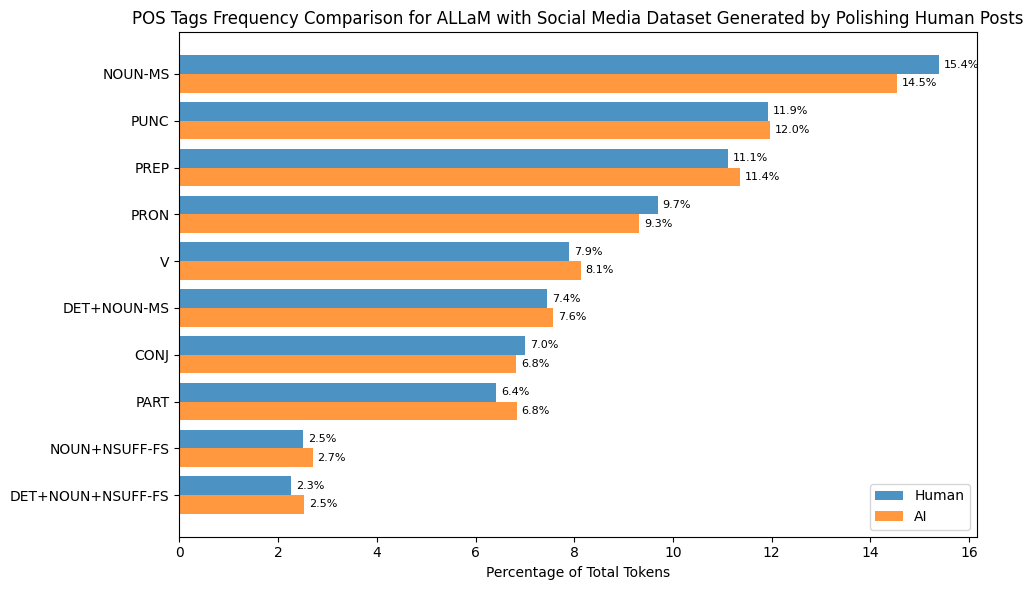

In [3]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/allam/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/allam/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for ALLaM with Social Media Dataset Generated by Polishing Human Posts",
    top_n=10,
)

#### NER

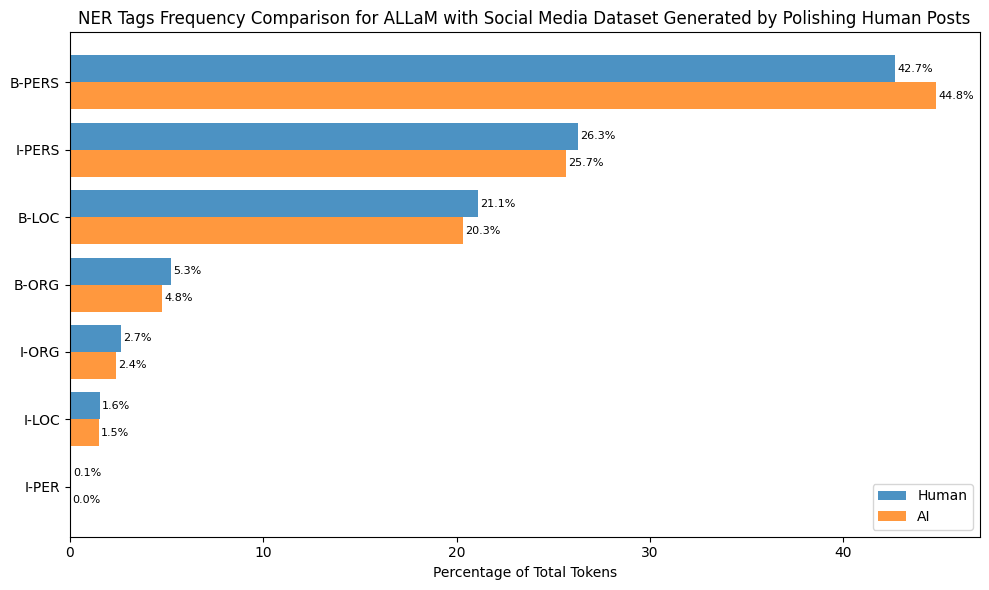

In [4]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/allam/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/allam/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for ALLaM with Social Media Dataset Generated by Polishing Human Posts",
    top_n=7,
)

## Llama

### By Polishing

#### POS

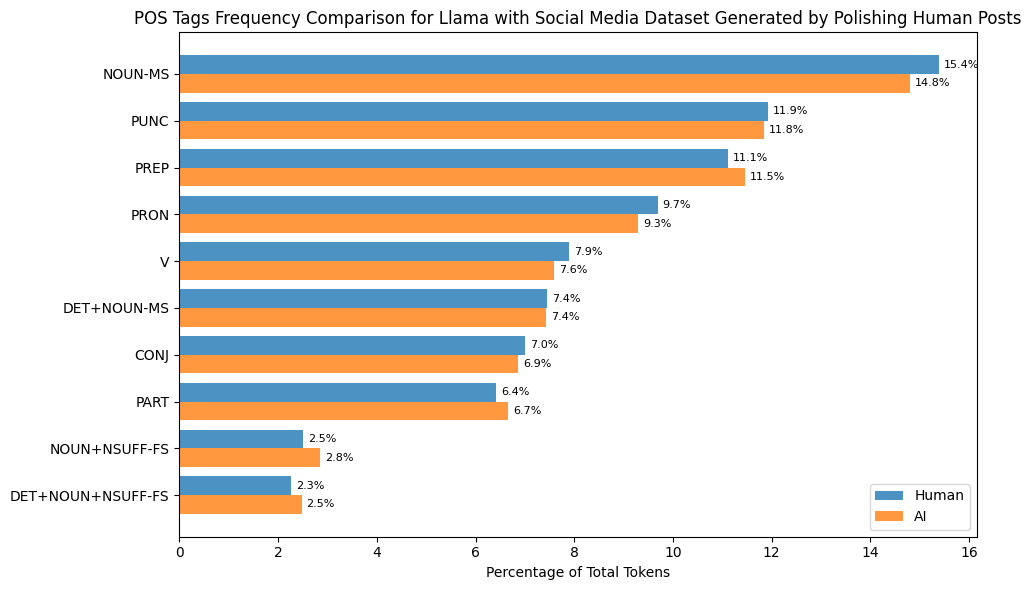

In [5]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/llama-batched/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/llama-batched/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for Llama with Social Media Dataset Generated by Polishing Human Posts",
    top_n=10,
)

#### NER

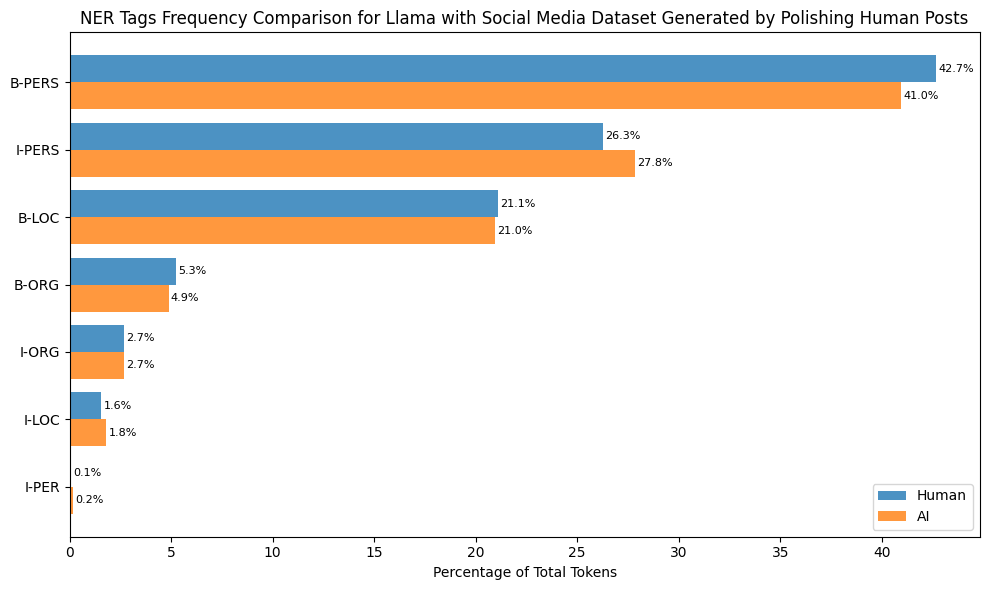

In [6]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/llama-batched/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/llama-batched/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for Llama with Social Media Dataset Generated by Polishing Human Posts",
    top_n=7,
)

## Jais

### By Polishing

#### POS

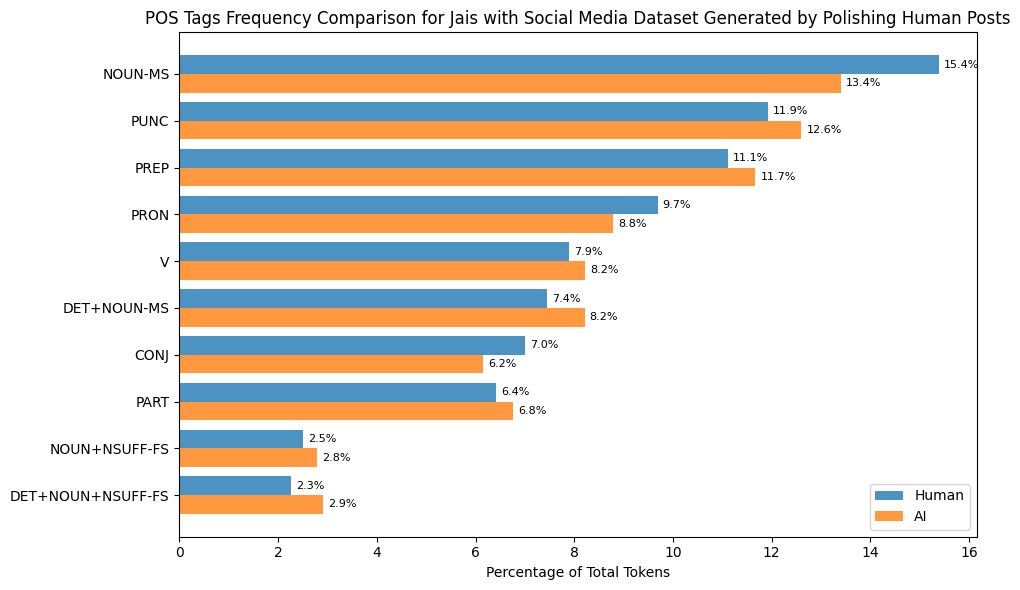

In [7]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/jais-batched/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/jais-batched/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for Jais with Social Media Dataset Generated by Polishing Human Posts",
    top_n=10,
)

#### NER

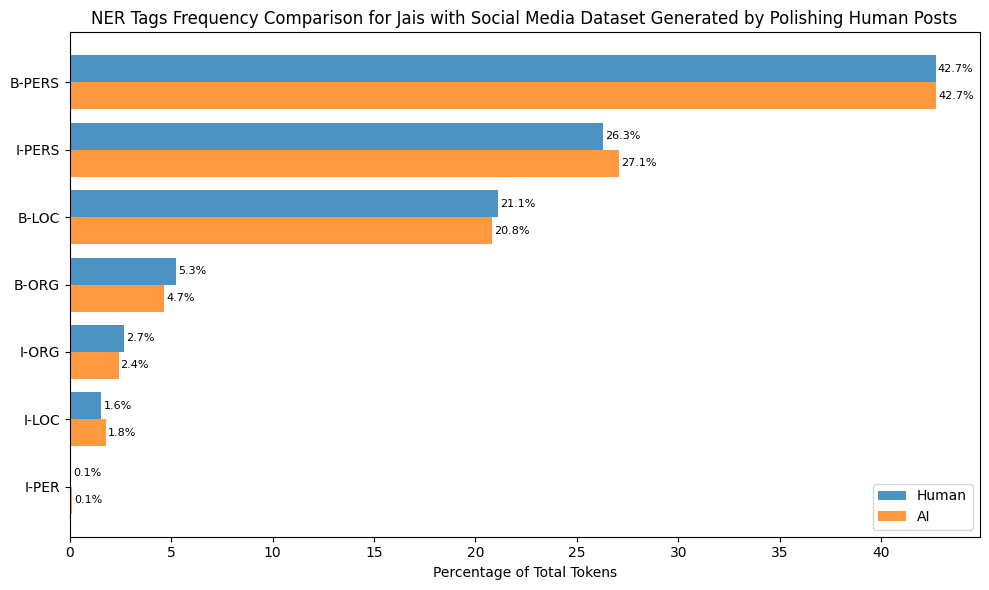

In [8]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/jais-batched/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/jais-batched/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for Jais with Social Media Dataset Generated by Polishing Human Posts",
    top_n=7,
)

## OpenAI

### By Polishing

#### POS

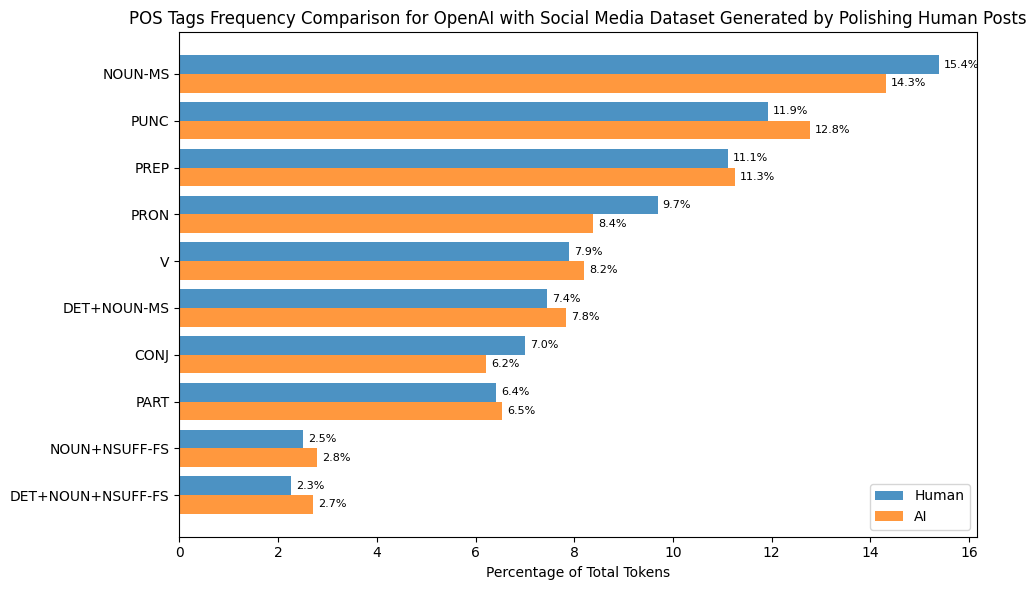

In [9]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/openai/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/openai/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for OpenAI with Social Media Dataset Generated by Polishing Human Posts",
    top_n=10,
)

#### NER

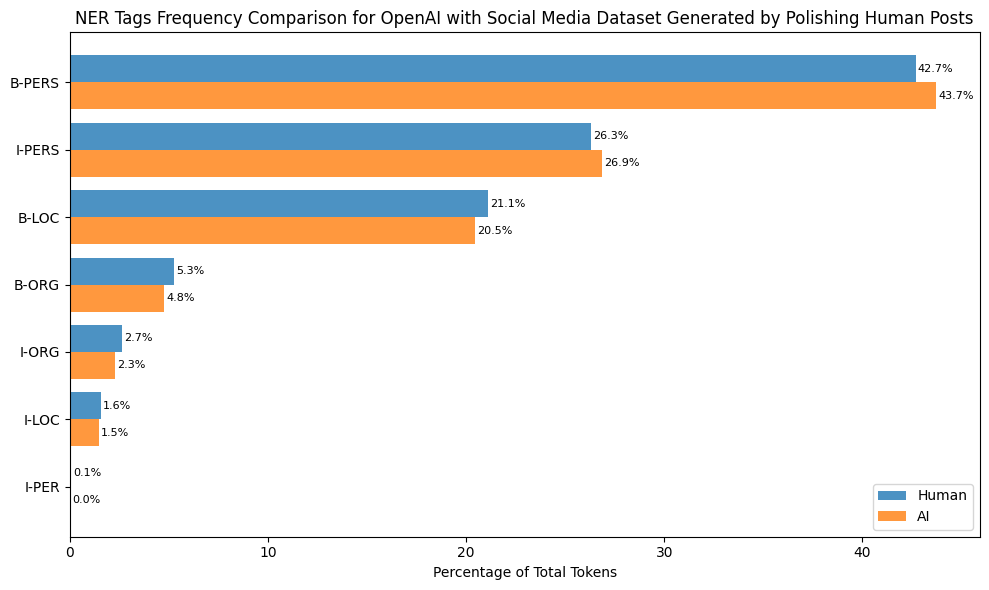

In [10]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/openai/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/social_media_dataset/openai/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for OpenAI with Social Media Dataset Generated by Polishing Human Posts",
    top_n=7,
)

# Abstracts Dataset

## ALLaM

### By Polishing

#### POS

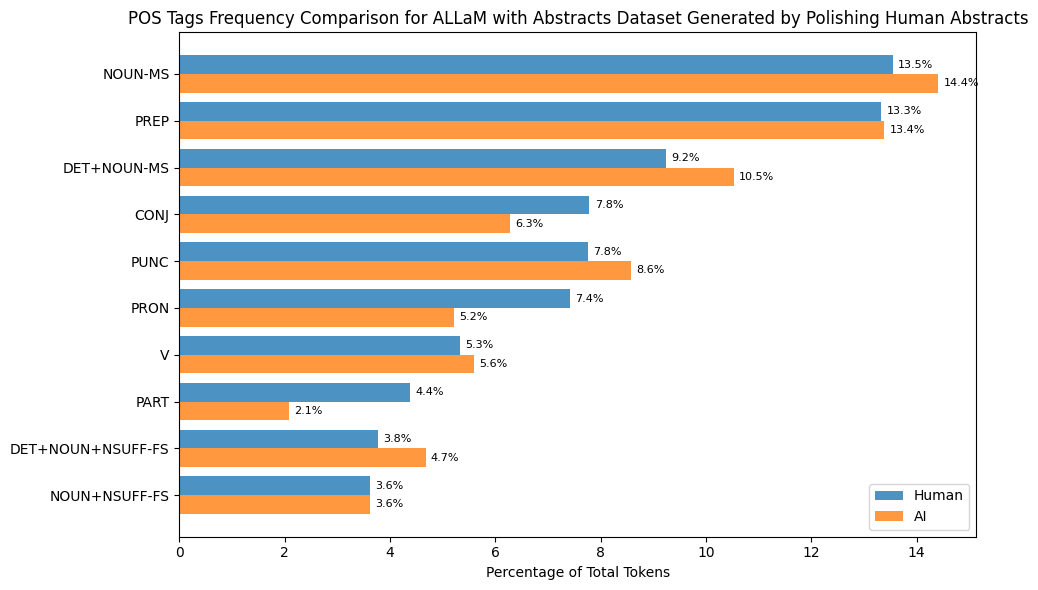

In [11]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/by_polishing/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/by_polishing/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for ALLaM with Abstracts Dataset Generated by Polishing Human Abstracts",
    top_n=10,
)

#### NER

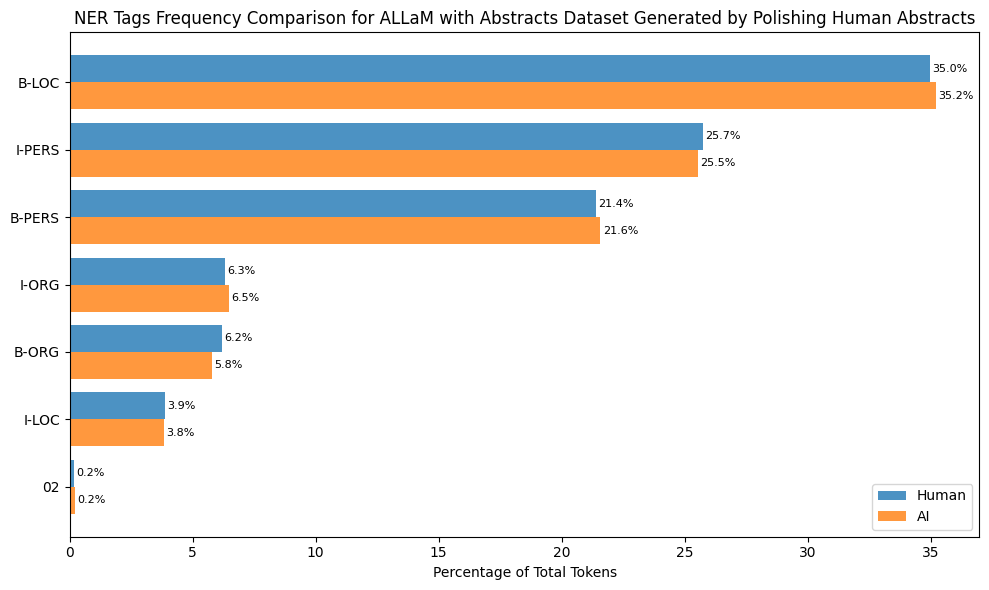

In [12]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/by_polishing/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/by_polishing/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for ALLaM with Abstracts Dataset Generated by Polishing Human Abstracts",
    top_n=7,
)

### from title

#### POS

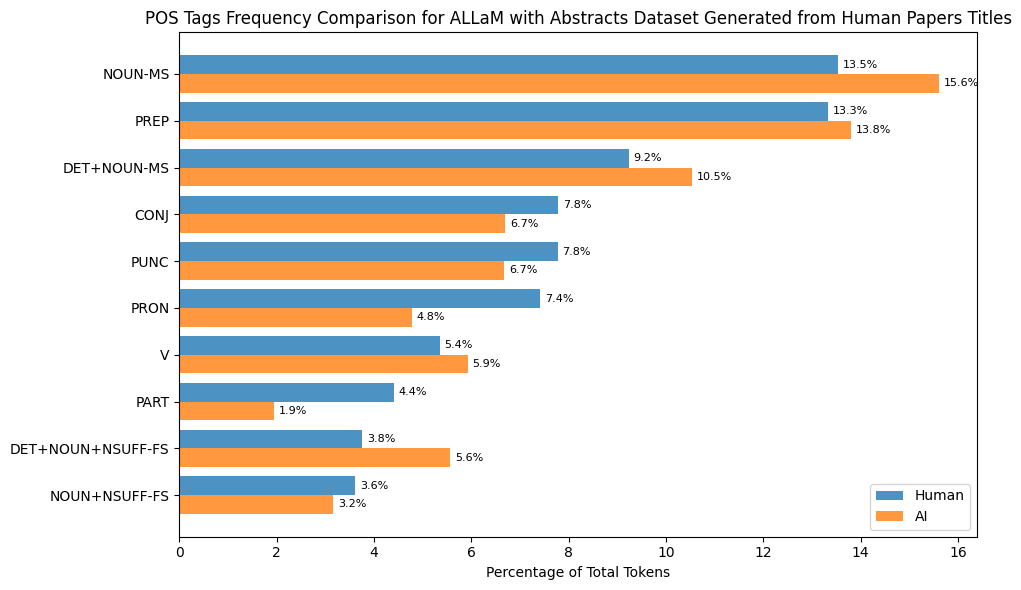

In [13]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/from_title/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/from_title/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for ALLaM with Abstracts Dataset Generated from Human Papers Titles",
    top_n=10,
)

#### NER

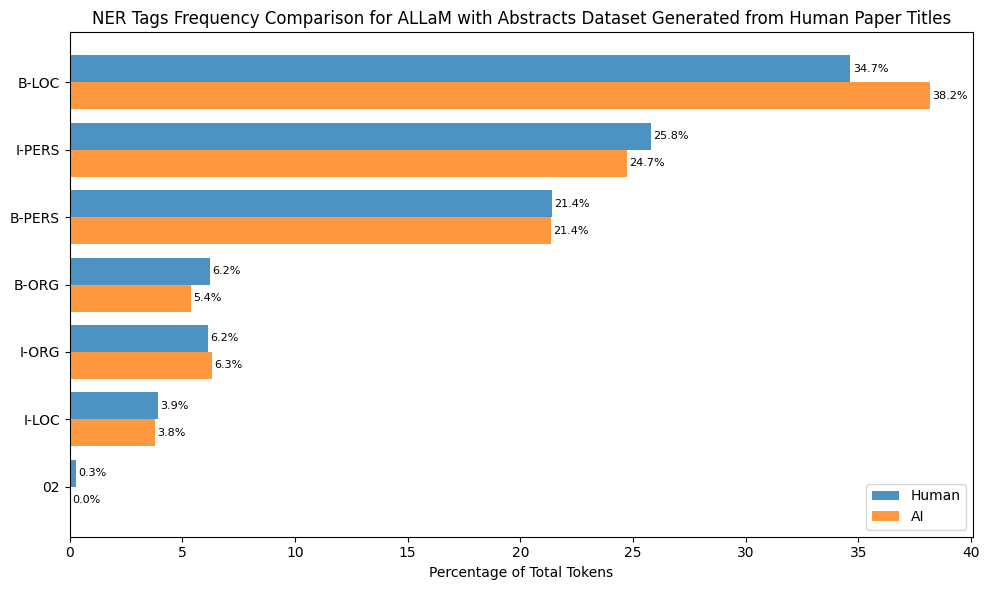

In [14]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/from_title/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/from_title/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for ALLaM with Abstracts Dataset Generated from Human Paper Titles",
    top_n=7,
)

### from title and content

#### POS

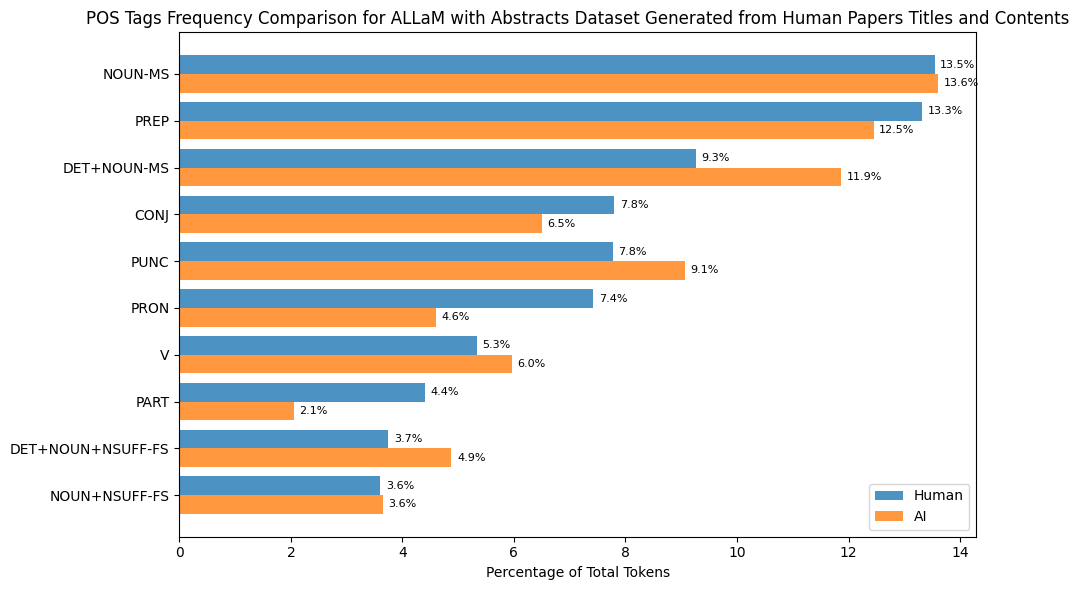

In [15]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/from_title_and_content/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/from_title_and_content/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for ALLaM with Abstracts Dataset Generated from Human Papers Titles and Contents",
    top_n=10,
)

#### NER

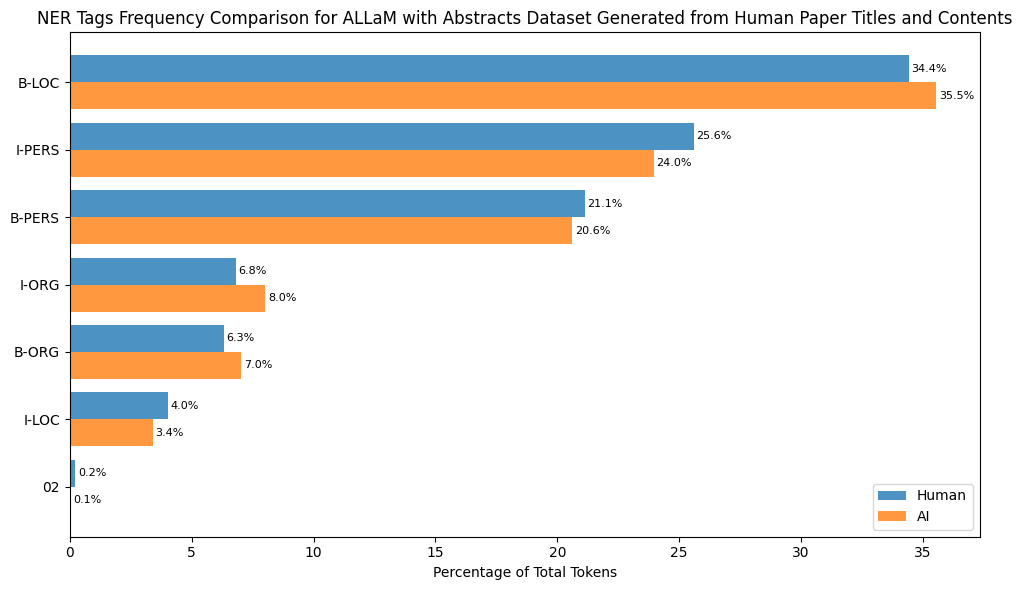

In [16]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/from_title_and_content/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/allam/from_title_and_content/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for ALLaM with Abstracts Dataset Generated from Human Paper Titles and Contents",
    top_n=7,
)

## Llama

### By Polishing

#### POS

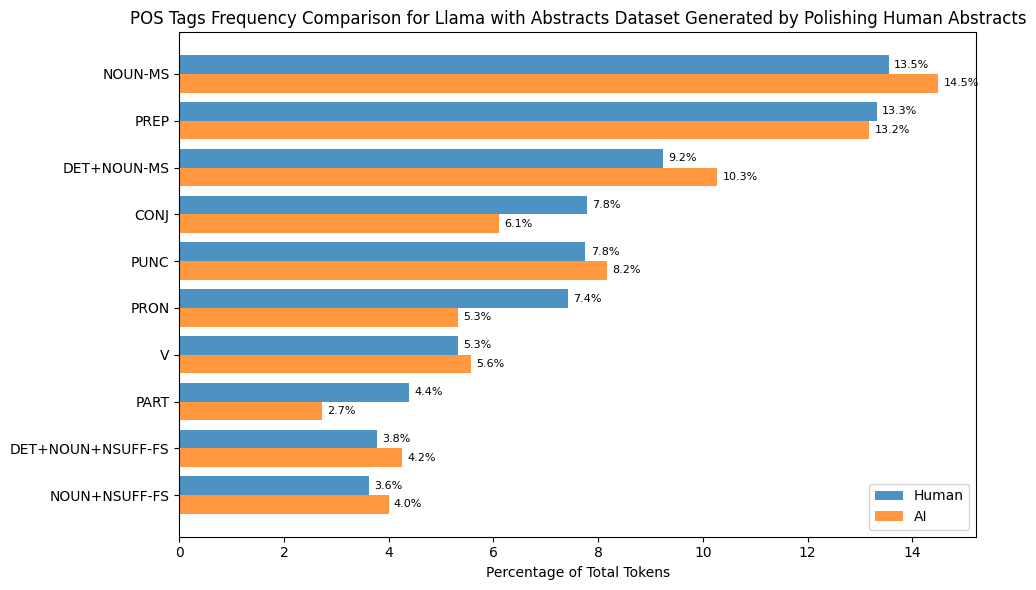

In [17]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/by_polishing/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/by_polishing/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for Llama with Abstracts Dataset Generated by Polishing Human Abstracts",
    top_n=10,
)

#### NER

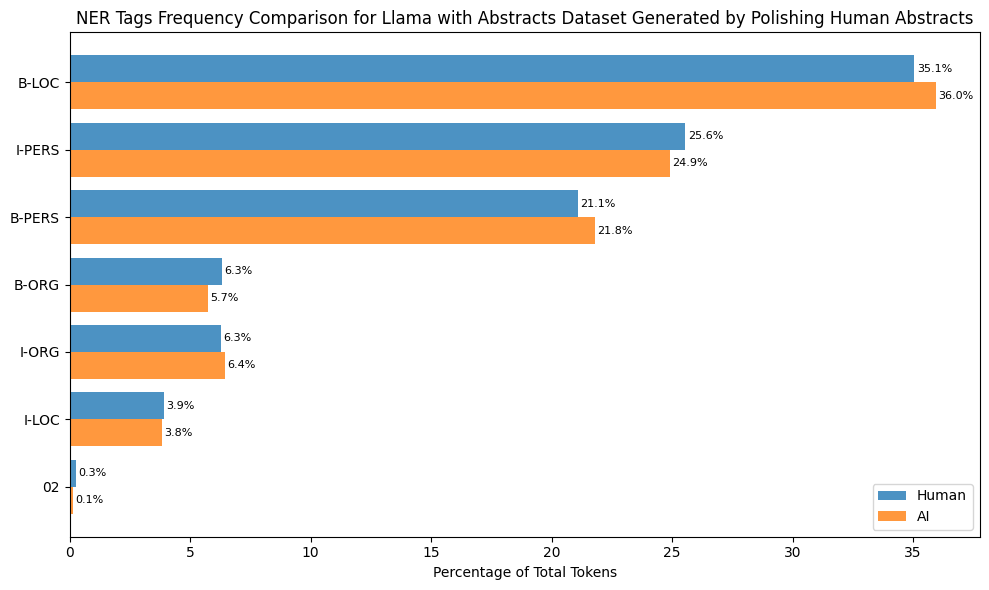

In [18]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/by_polishing/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/by_polishing/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for Llama with Abstracts Dataset Generated by Polishing Human Abstracts",
    top_n=7,
)

### From Title

#### POS

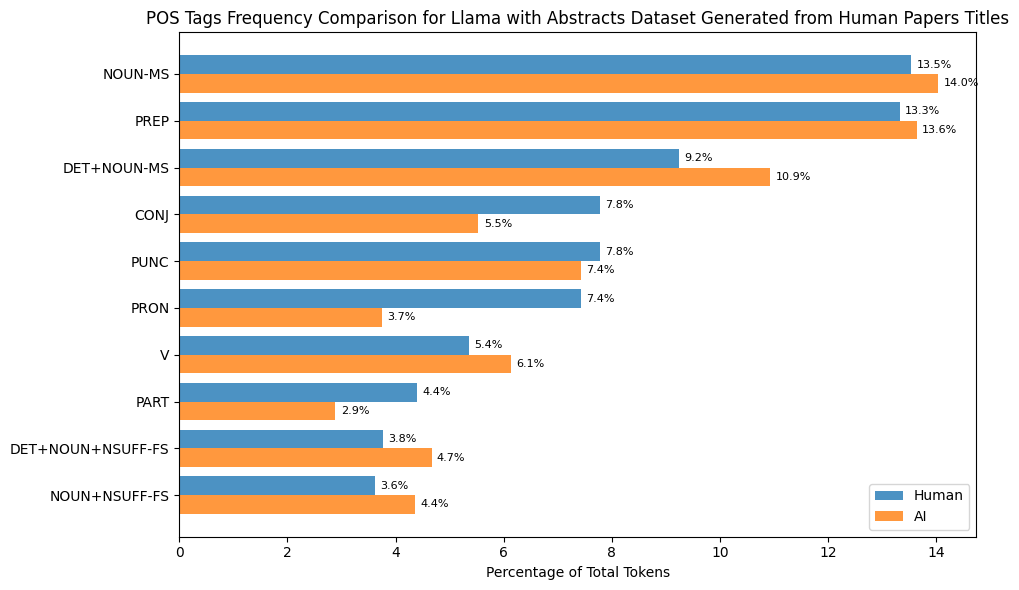

In [19]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/from_title/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/from_title/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for Llama with Abstracts Dataset Generated from Human Papers Titles",
    top_n=10,
)

#### NER

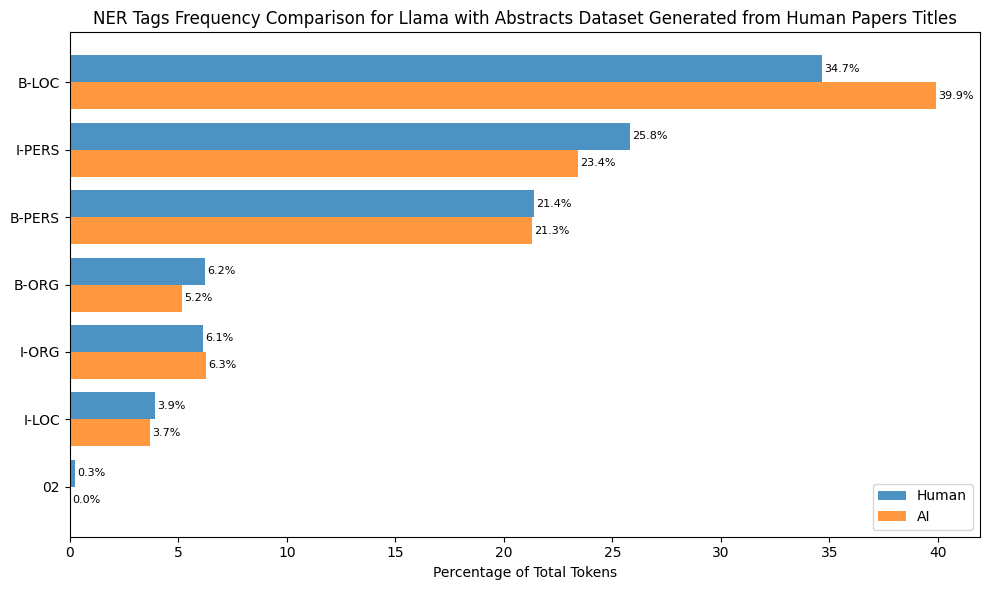

In [20]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/from_title/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/from_title/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for Llama with Abstracts Dataset Generated from Human Papers Titles",
    top_n=7,
)

### From title and content

#### POS

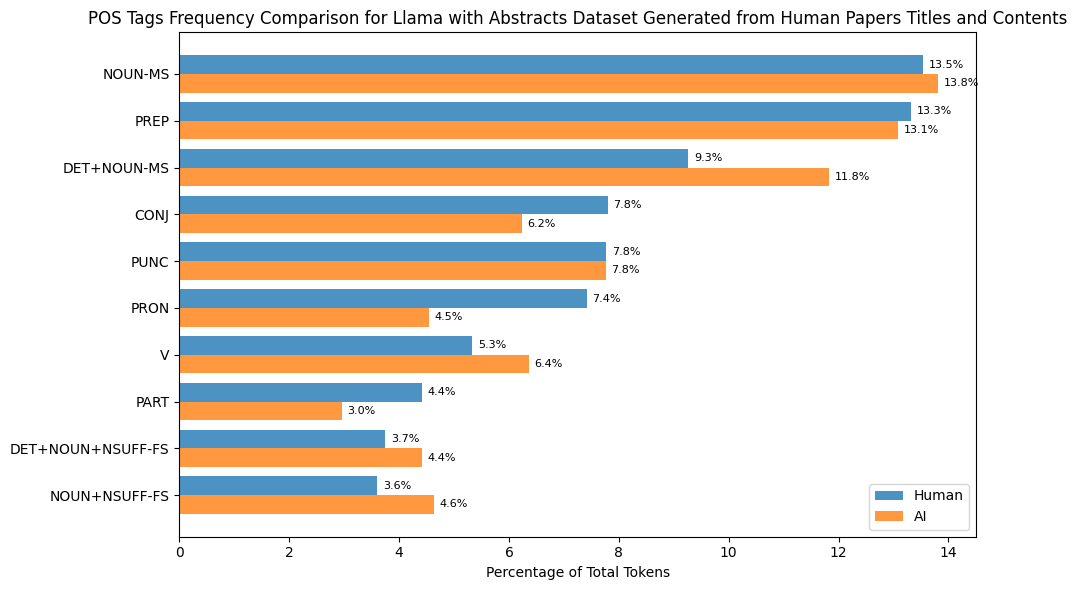

In [21]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/from_title_and_content/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/from_title_and_content/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for Llama with Abstracts Dataset Generated from Human Papers Titles and Contents",
    top_n=10,
)

#### NER

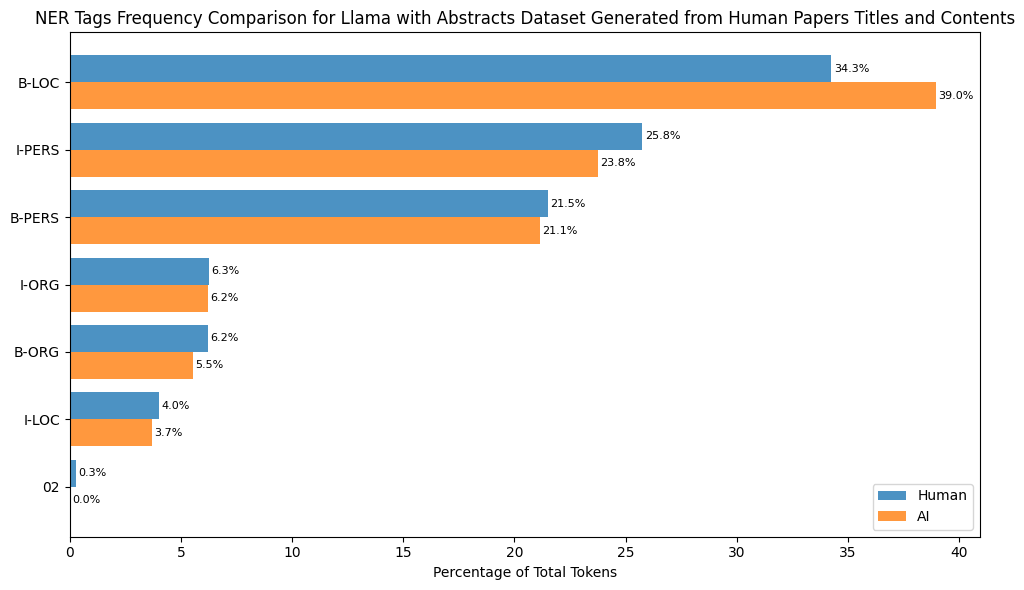

In [22]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/from_title_and_content/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/llama-batched/from_title_and_content/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for Llama with Abstracts Dataset Generated from Human Papers Titles and Contents",
    top_n=7,
)

## Jais

### By Polishing

#### POS

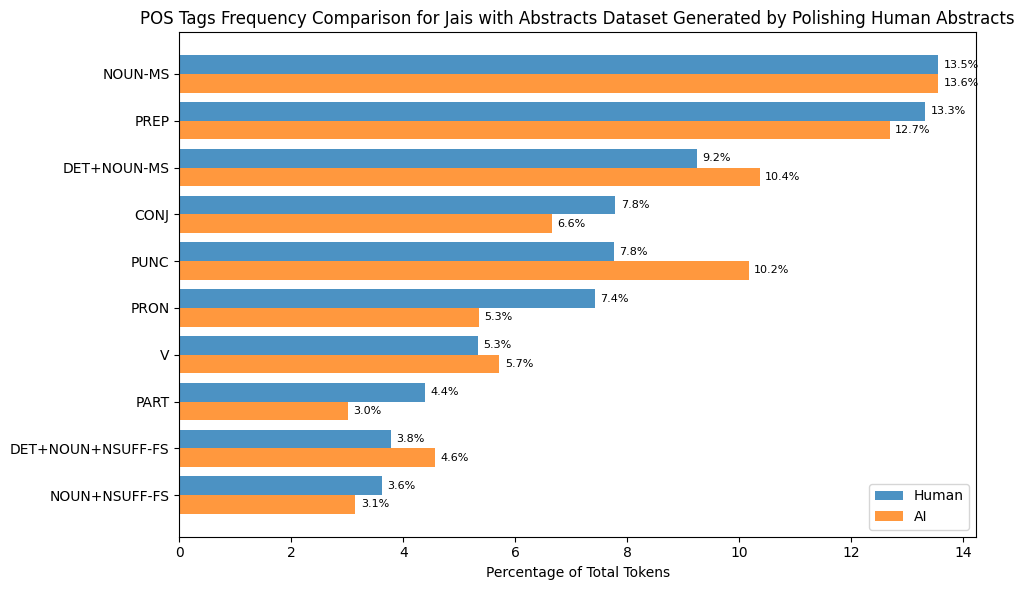

In [23]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/by_polishing/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/by_polishing/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for Jais with Abstracts Dataset Generated by Polishing Human Abstracts",
    top_n=10,
)

#### NER

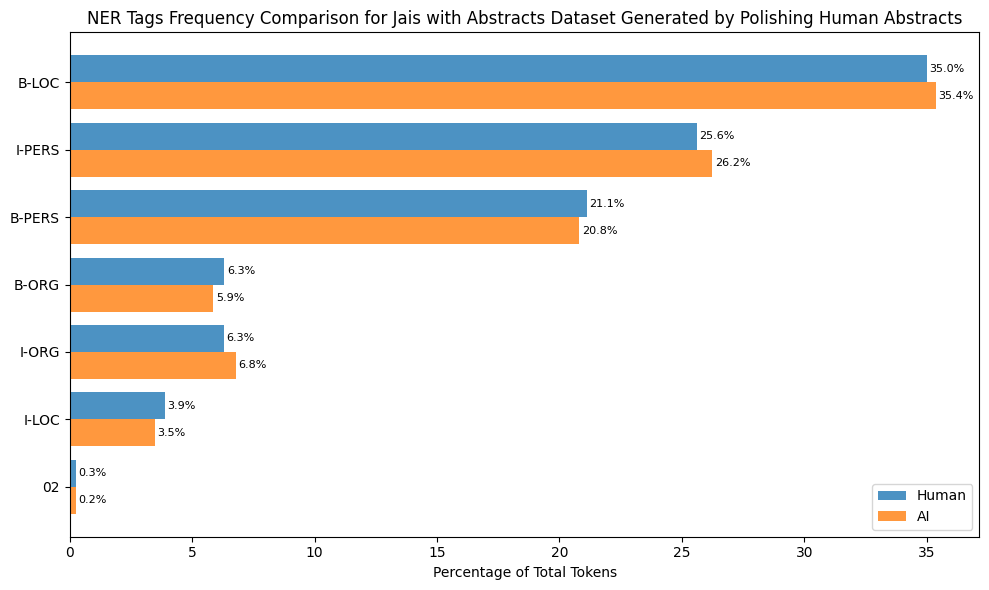

In [24]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/by_polishing/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/by_polishing/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for Jais with Abstracts Dataset Generated by Polishing Human Abstracts",
    top_n=7,
)

### From Title

#### POS

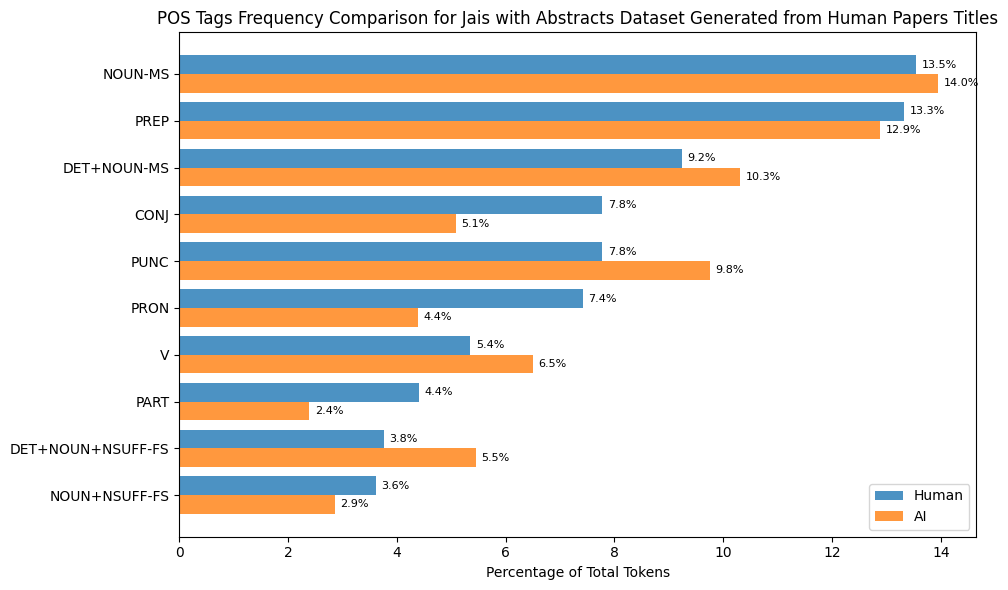

In [25]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/from_title/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/from_title/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for Jais with Abstracts Dataset Generated from Human Papers Titles",
    top_n=10,
)

#### NER

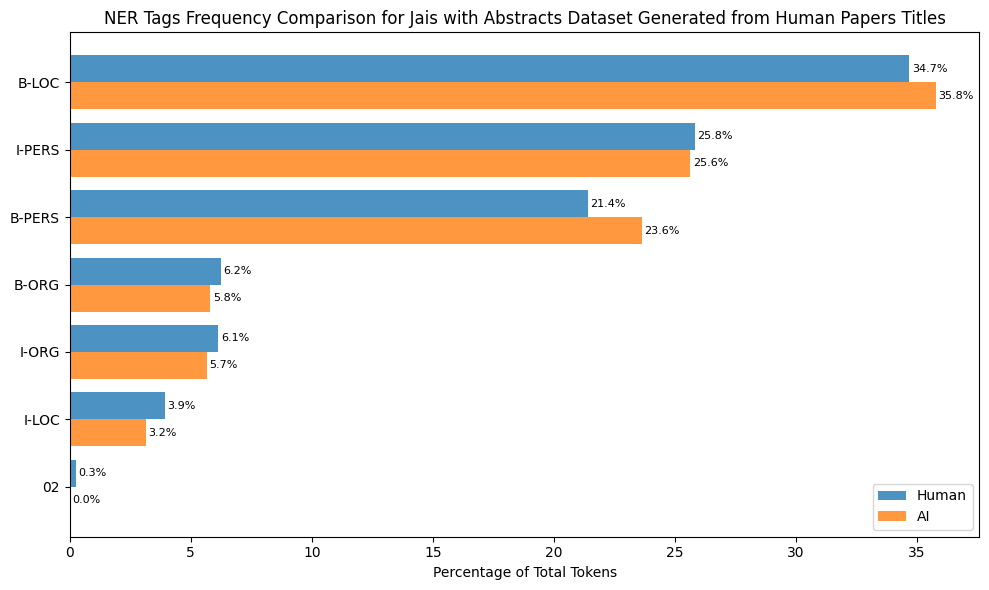

In [26]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/from_title/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/from_title/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for Jais with Abstracts Dataset Generated from Human Papers Titles",
    top_n=7,
)

### From Title and Content

#### POS

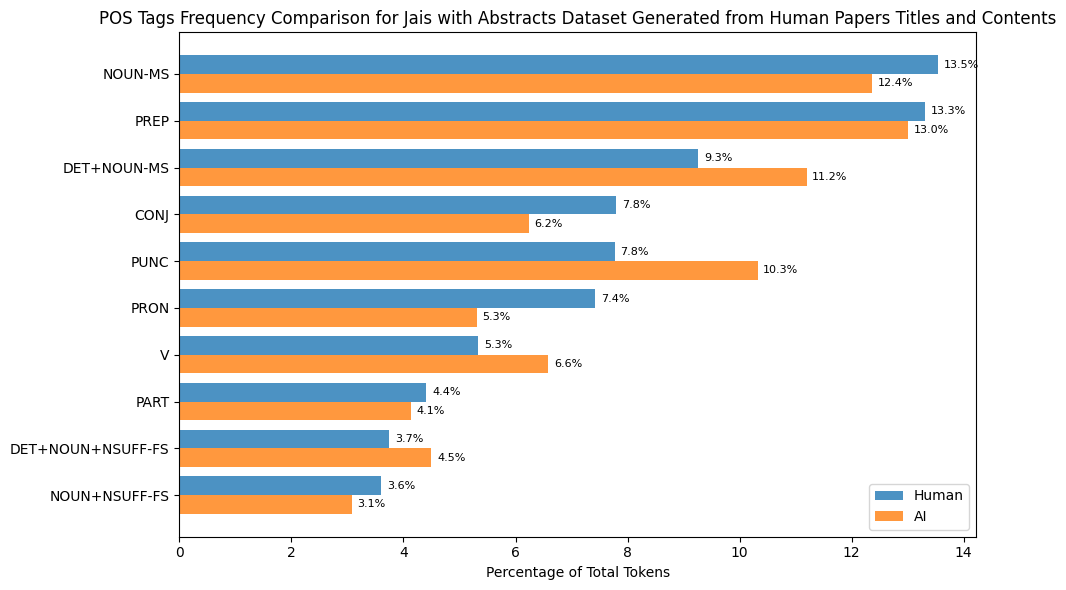

In [27]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/from_title_and_content/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/from_title_and_content/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for Jais with Abstracts Dataset Generated from Human Papers Titles and Contents",
    top_n=10,
)

#### NER

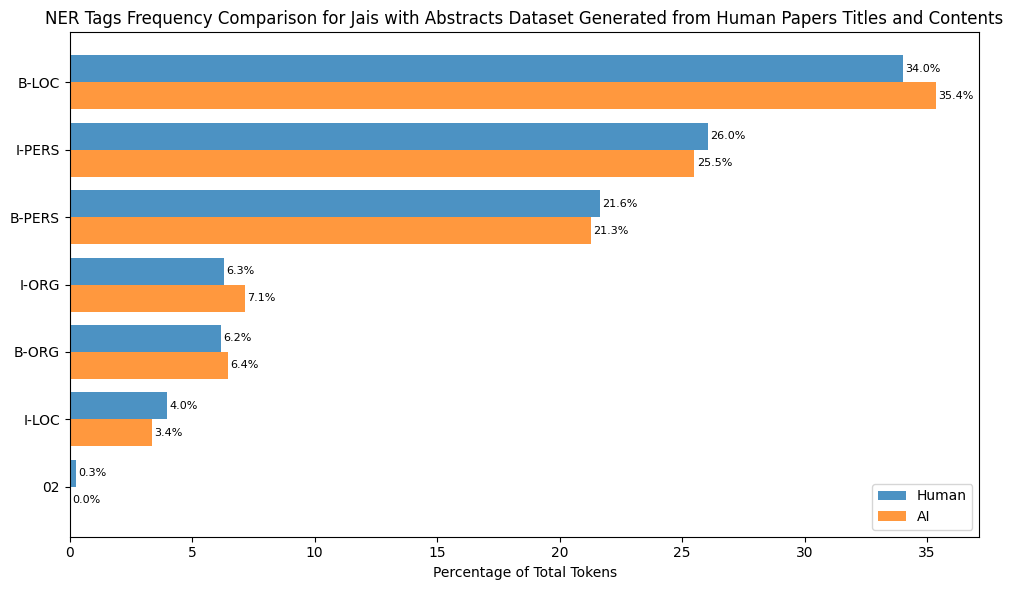

In [28]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/from_title_and_content/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/jais-batched/from_title_and_content/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for Jais with Abstracts Dataset Generated from Human Papers Titles and Contents",
    top_n=7,
)

## OpenAI

### By Polishing

#### POS

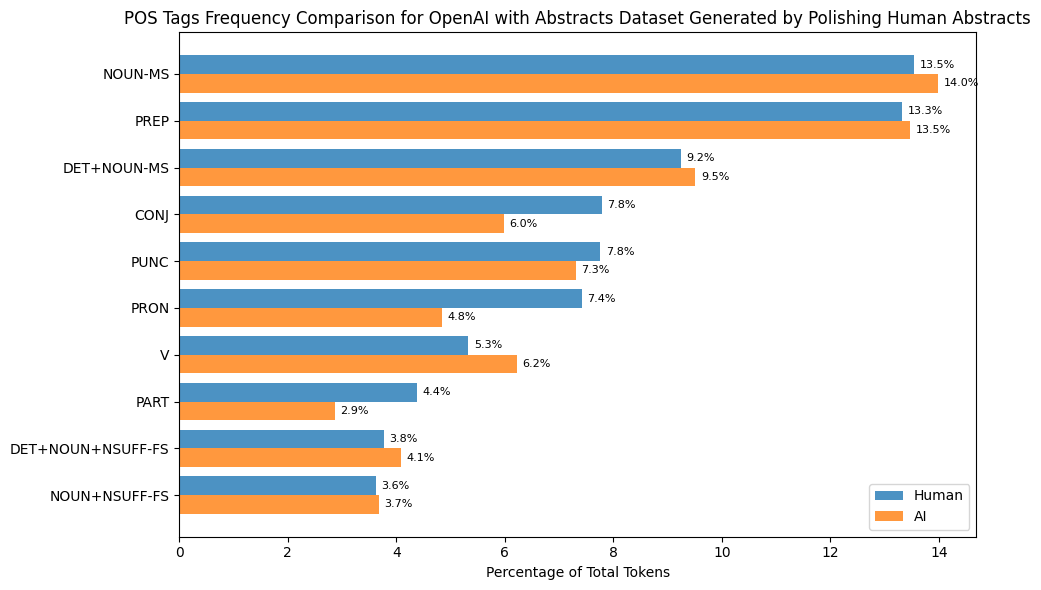

In [29]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/by_polishing/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/by_polishing/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for OpenAI with Abstracts Dataset Generated by Polishing Human Abstracts",
    top_n=10,
)

#### NER

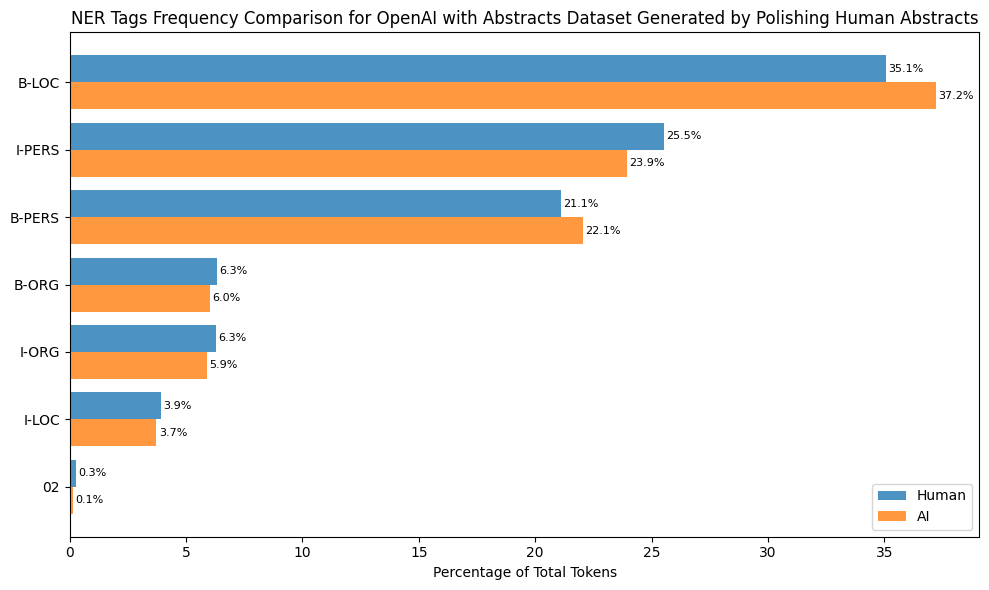

In [30]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/by_polishing/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/by_polishing/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for OpenAI with Abstracts Dataset Generated by Polishing Human Abstracts",
    top_n=7,
)

### From Title

#### POS

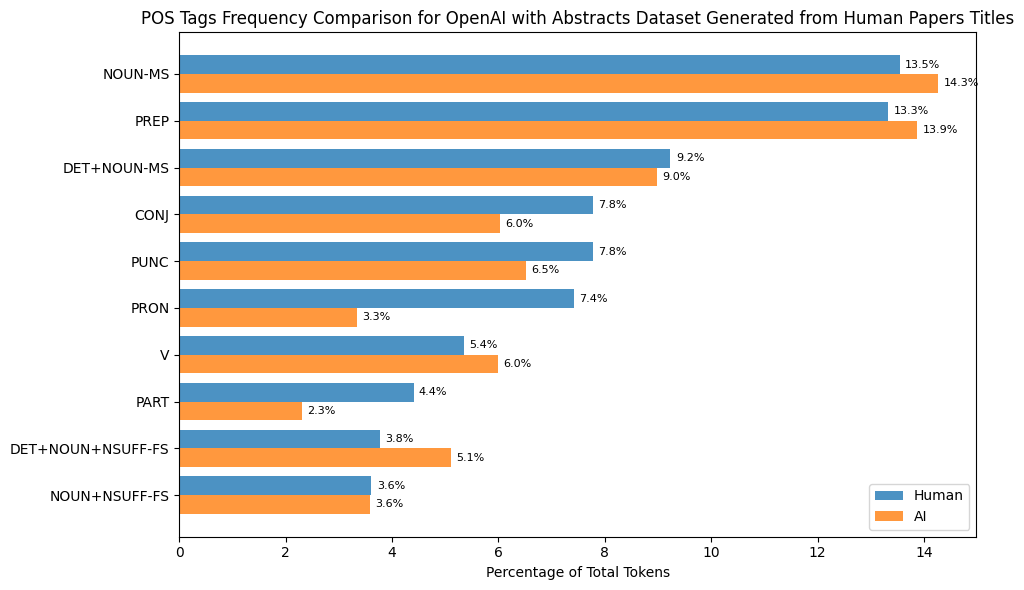

In [31]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/from_title/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/from_title/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for OpenAI with Abstracts Dataset Generated from Human Papers Titles",
    top_n=10,
)

#### NER

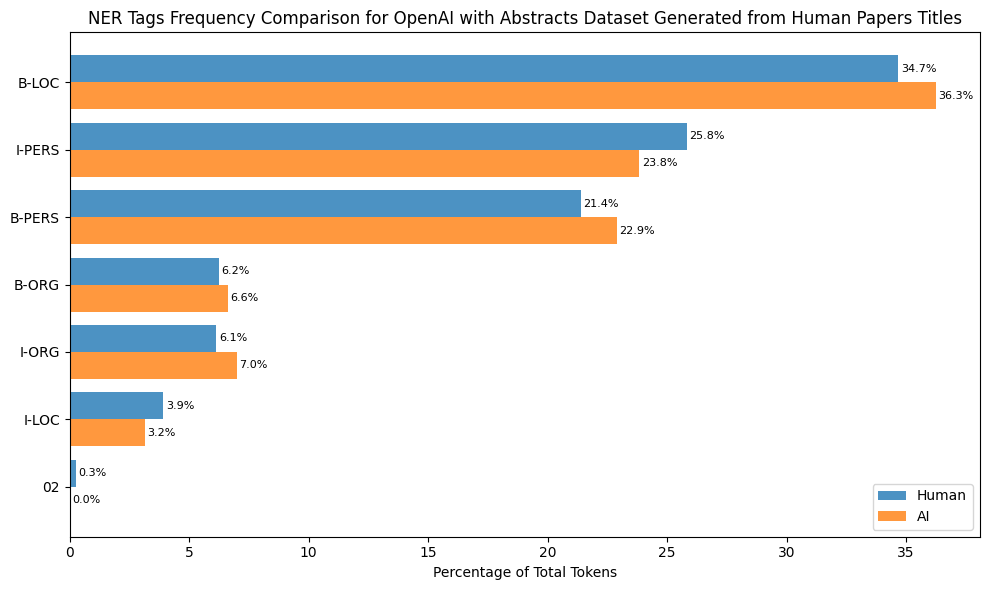

In [32]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/from_title/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/from_title/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for OpenAI with Abstracts Dataset Generated from Human Papers Titles",
    top_n=7,
)

### From Title and Content

#### POS

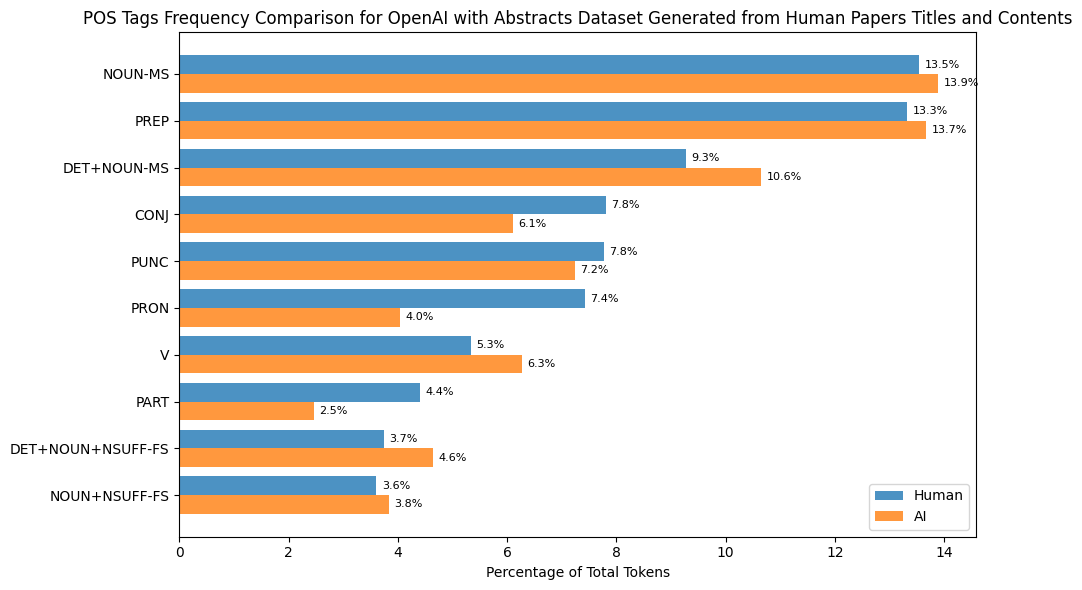

In [33]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/from_title_and_content/human_pos_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/from_title_and_content/ai_pos_counts.json",
    title="POS Tags Frequency Comparison for OpenAI with Abstracts Dataset Generated from Human Papers Titles and Contents",
    top_n=10,
)

#### NER

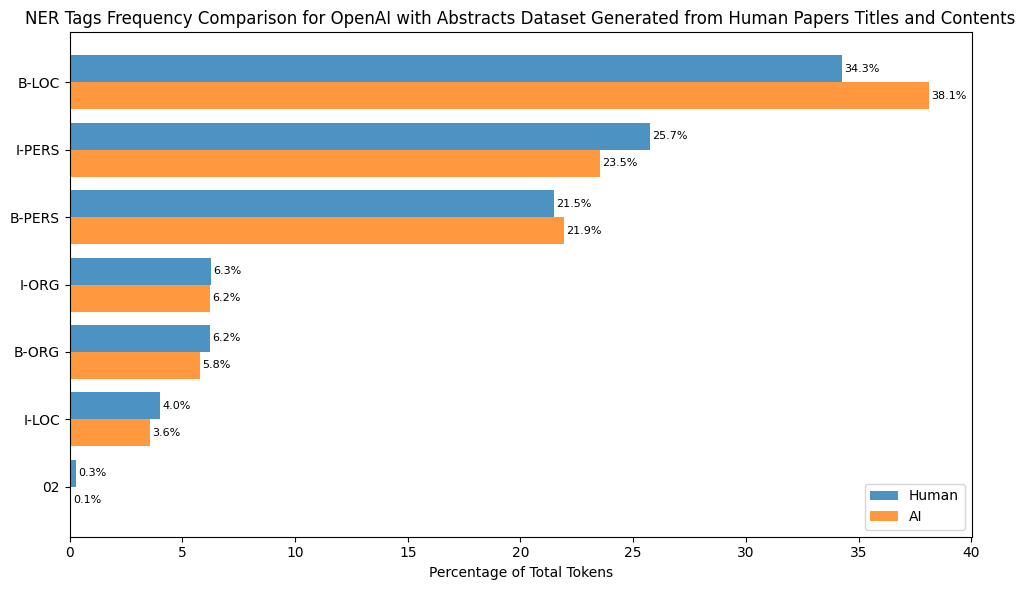

In [34]:
analyze_frequencies(
    human_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/from_title_and_content/human_ner_counts.json",
    ai_frequency_jsonpath="notebooks/stylometric_analysis/abstracts_dataset/openai/from_title_and_content/ai_ner_counts.json",
    title="NER Tags Frequency Comparison for OpenAI with Abstracts Dataset Generated from Human Papers Titles and Contents",
    top_n=7,
)